# Importación de las librerías necesarias para la ejecución #

In [1]:
#Librerias Necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense
from keras import backend as K

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
#from sklearn.preprocessing import scale

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Lectura de los datos de los partidos ya formateados en .csv

In [2]:
datos_partidos=pd.read_csv('../Segundo_Dataset/Datos_Formateados/datos-1516.csv') 
datos_partidos.shape

(380, 9)

In [3]:
datos_partidos.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,FTR
0,SP1,21/08/15,Malaga,Sevilla,0,0,0,0,D
1,SP1,22/08/15,Ath Madrid,Las Palmas,1,0,1,0,H
2,SP1,22/08/15,Espanol,Getafe,1,0,1,0,H
3,SP1,22/08/15,La Coruna,Sociedad,0,0,0,0,D
4,SP1,22/08/15,Vallecano,Valencia,0,0,0,0,D


In [4]:
def get_equipos(dataframe: pd.DataFrame) -> list:
    list = []
    for idx in dataframe.index:
        if dataframe['HomeTeam'][idx] not in list:
            list.append(dataframe['HomeTeam'][idx])
        if dataframe['AwayTeam'][idx] not in list:
            list.append(dataframe['AwayTeam'][idx])
    return list

equipos = get_equipos(dataframe=datos_partidos)
equipos

['Malaga',
 'Sevilla',
 'Ath Madrid',
 'Las Palmas',
 'Espanol',
 'Getafe',
 'La Coruna',
 'Sociedad',
 'Vallecano',
 'Valencia',
 'Ath Bilbao',
 'Barcelona',
 'Betis',
 'Villarreal',
 'Levante',
 'Celta',
 'Sp Gijon',
 'Real Madrid',
 'Granada',
 'Eibar']

# Predicción del ganador de una partido sabiendo resultado final e intermedio #

## - Pre-procesamiento de los datos ##

### Asignación de etiquetas numéricas a los posibles valores de FTR ###

In [5]:
lb_make = LabelEncoder()
datos_partidos['target FTR'] = lb_make.fit_transform(datos_partidos['FTR'])
datos_partidos['FTR'].value_counts()

FTR
H    183
A    105
D     92
Name: count, dtype: int64

In [6]:
datos_partidos['target FTR'].value_counts()

target FTR
2    183
0    105
1     92
Name: count, dtype: int64

### Definición de los predictores y del objetivo de predicción ###
| Variable | Descripción
| :-------- | :-------:
| FTHG | Goles finales equipo local
| FTAG | Goles finales equipo visitante
| HTHG | Goles intermedios equipo local
| HTAG | Goles intermedios equipo visitante
| FTR | Ganador del partido (Home, Draw, Away)
| target FTR | Ganador del partido (2, 1, 0)

In [7]:
columns_name=['FTHG','FTAG','HTHG','HTAG']
features = datos_partidos[columns_name]
target = datos_partidos['target FTR']

### Separación del objetivo de predicción en clases binarias

In [8]:
target = to_categorical(target)
target.shape

(380, 3)

## - Normalización de los datos

Los diferentes datos utilizados tienen un rango de valores bastante desigual. Es necesario encontrar un método de normalización para que estos rangos sean más similares además de lo más próximos a [0,1] posible

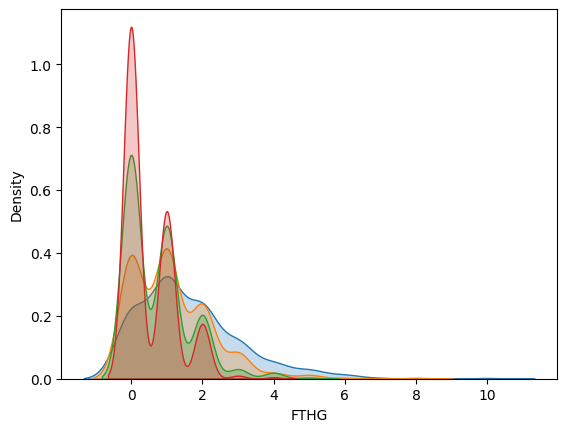

In [9]:
for col in features:
    sns.kdeplot(features[col], fill=True)

### 1. Estandarización

### $z = \frac{x_i + \mu}{\sigma}$ ### 

In [10]:
scale = StandardScaler().fit(features)
features_standarized = scale.transform(features)
features_standarized_dataframe = pd.DataFrame(features_standarized, columns=columns_name)
features_standarized_dataframe.head()

,FTHG,FTAG,HTHG,HTAG
0,-1.117047,-0.981961,-0.826003,-0.712697
1,-0.426839,-0.981961,0.287051,-0.712697
2,-0.426839,-0.981961,0.287051,-0.712697
3,-1.117047,-0.981961,-0.826003,-0.712697
4,-1.117047,-0.981961,-0.826003,-0.712697


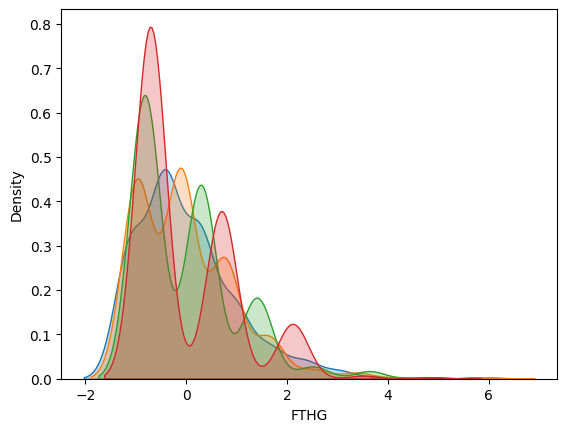

In [11]:
for col in features_standarized_dataframe:
    sns.kdeplot(features_standarized_dataframe[col], fill=True)

### 2. Normalizar

### $z = \frac{x - min(x)}{max(x) - min(x)}$ ### 

In [12]:
scale_2 = MinMaxScaler().fit(features)
features_normalized = scale_2.transform(features)
features_normalized_dataframe = pd.DataFrame(features_normalized, columns=columns_name)
features_normalized_dataframe.head()

,FTHG,FTAG,HTHG,HTAG
0,0.0,0.0,0.0,0.0
1,0.1,0.0,0.2,0.0
2,0.1,0.0,0.2,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0


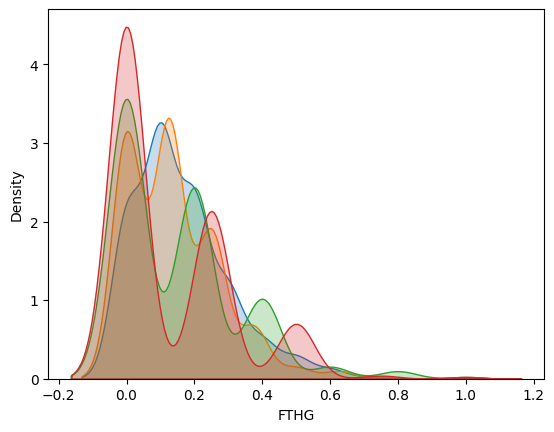

In [13]:
for col in features_normalized_dataframe:
    sns.kdeplot(features_normalized_dataframe[col], fill=True)

El método de normalización acerca los rangos a [0,1] así que usaremos este método para normalizar los datos

## - Entrenamiento del modelo

### División del dataset en entrenamiento y evaluación del modelo

In [14]:
features_train, features_test, target_train, target_test = train_test_split( features_normalized_dataframe, target, test_size=0.3, random_state=4)
print ('Train set:', features_train.shape,  target_train.shape)
print ('Test set:', features_test.shape,  target_test.shape)
print (features_normalized_dataframe.shape)

Train set: (266, 4) (266, 3)
Test set: (114, 4) (114, 3)
(380, 4)


### Definición y construcción del modelo

In [15]:
def get_modelo_regresion(features: pd.DataFrame) -> Sequential:
    numero_predictores = features.shape[1]
    #Crear el modelo
    model = Sequential()
    model.add(Dense(10, activation='relu', input_shape=(numero_predictores,)))
    model.add(Dense(10, activation='relu'))
    model.add(Dense(10, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    
    #Compilar modelo
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

modelo = get_modelo_regresion(features=features)

### Entrenamiento del modelo

In [16]:
iteraciones=100
historial_entrenamiento=modelo.fit(features_train, target_train, validation_data=(features_test,target_test), epochs=iteraciones, verbose=1)

Epoch 1/100
9/9 [==============================] - 2s 49ms/step - loss: 1.0994 - accuracy: 0.3534 - val_loss: 1.0954 - val_accuracy: 0.4123
Epoch 2/100
9/9 [==============================] - 0s 10ms/step - loss: 1.0926 - accuracy: 0.4925 - val_loss: 1.0897 - val_accuracy: 0.4298
Epoch 3/100
9/9 [==============================] - 0s 10ms/step - loss: 1.0866 - accuracy: 0.5038 - val_loss: 1.0840 - val_accuracy: 0.4298
Epoch 4/100
9/9 [==============================] - 0s 9ms/step - loss: 1.0807 - accuracy: 0.5038 - val_loss: 1.0783 - val_accuracy: 0.4298
Epoch 5/100
9/9 [==============================] - 0s 10ms/step - loss: 1.0739 - accuracy: 0.5038 - val_loss: 1.0727 - val_accuracy: 0.4298
Epoch 6/100
9/9 [==============================] - 0s 11ms/step - loss: 1.0675 - accuracy: 0.5038 - val_loss: 1.0665 - val_accuracy: 0.4298
Epoch 7/100
9/9 [==============================] - 0s 10ms/step - loss: 1.0598 - accuracy: 0.5038 - val_loss: 1.0603 - val_accuracy: 0.4298
Epoch 8/100
9/9 [====

## -Evaluación del modelo

### Evolución del modelo

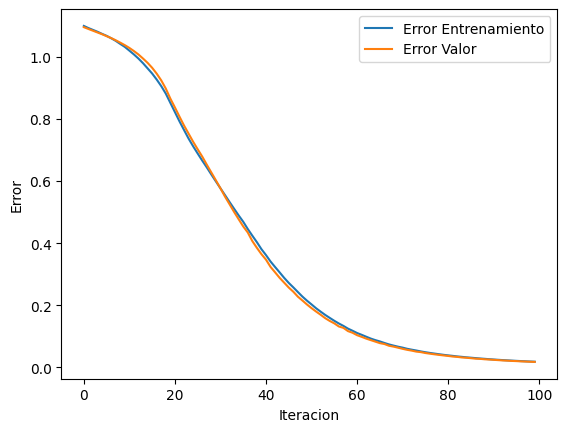

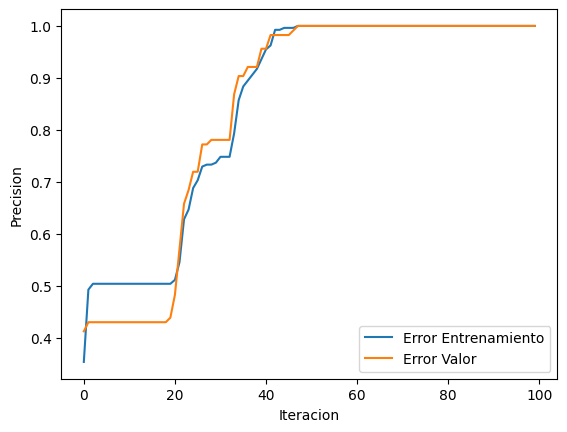

In [17]:
def plot_entrenamiento(historial):
    hist = pd.DataFrame(historial.history)
    hist['iteracion'] = historial.epoch

    plt.figure()
    plt.xlabel('Iteracion')
    plt.ylabel('Error')
    plt.plot(hist['iteracion'], hist['loss'],label='Error Entrenamiento')
    plt.plot(hist['iteracion'], hist['val_loss'],label = 'Error Valor')
    plt.legend()
    
    plt.figure()
    plt.xlabel('Iteracion')
    plt.ylabel('Precision')
    plt.plot(hist['iteracion'], hist['accuracy'],label='Error Entrenamiento')
    plt.plot(hist['iteracion'], hist['val_accuracy'],label = 'Error Valor')
    plt.legend()
    
    plt.show()
    
plot_entrenamiento(historial = historial_entrenamiento)

### Evaluación

In [ ]:
test1 = modelo.evaluate(features_test, target_test, verbose=0)
print('Test loss:', round(test1[0],3)) 
print('Test accuracy:', round(test1[1],3))

## - Predicción real de un partido

In [ ]:
HT='Real Madrid'
AT='Barcelona'
datos_partido_a_predecir=datos_partidos.loc[(datos_partidos['HomeTeam']==HT) & (datos_partidos['AwayTeam']==AT)]
print(datos_partido_a_predecir.shape)
print(datos_partido_a_predecir)

### Separar los predictores de la columna objetivo

In [ ]:
features_2 = datos_partido_a_predecir[['FTHG','FTAG','HTHG','HTAG']]
target_2 = datos_partido_a_predecir[['target FTR']]
features_2

In [ ]:
target_2

### Conseguir el ganador real a partir del número de target FTR

In [ ]:
def get_ganador_real(ganador) -> str:
    if (int(ganador)==0):
      winner='Away'
    elif (int(ganador)==1):
      winner='Draw'
    else:
      winner='Home'
    return winner

ganador_real=get_ganador_real(target_2.iloc[0])

### Normalizar los predictores teniendo en cuenta los predictores usados para el entrenamiento del modelo

In [ ]:
features_2_normalized = (features_2 - features.mean()) / features.std()

### Predicción del valor objetivo

In [ ]:
pred1 = modelo.predict(features_2_normalized)
pred1

### Conversión del número devuelto
Puede que el valor de las probabilidades devuelto por el modelo sea muy pequeño así que se opera para ser un número más manejable

In [ ]:
def convertir_numbero(prediccion: list) -> list:
    prediccion_valores=[]
    for i in range(len(prediccion[0])):
      pred_number=float(format(prediccion[0][i], '.3f'))
      prediccion_valores.append(pred_number)

    return (prediccion_valores)
  
pred1_number_probabilities=convertir_numbero(pred1)

### Obtención del resultado predicho en base a las probabilidades predichas por el modelo

In [ ]:
def get_ganador_prediccion(ganador: list) -> str:
    y=ganador.index(max(ganador))
    if y==0:
        pred_winner='Away'
    elif y==1:
        pred_winner='Draw'
    else:
        pred_winner='Home'
    return pred_winner

ganador_predicho=get_ganador_prediccion(pred1_number_probabilities)

### Resultado Final

In [ ]:
print('El ganador real es: ', ganador_real)
print('El ganador predicho es: ',ganador_predicho)

### Visualización de las probabilidades en una gráfica

In [ ]:
etiquetas = 'Away', 'Draw', 'Home'
figureObject, axesObject = plt.subplots()
axesObject.pie(pred1_number_probabilities, labels=etiquetas, autopct='%1.2f', startangle=90)
axesObject.axis('equal') # Aspect ratio equal means pie is a circle
plt.show()